# Preprocessing Temporal Data

## Table of Contents

1. [Dataset Description - Bitcoin Historical Market Data](#dataset-description---bitcoin-historical-market-data)
   - [Dataset Overview](#dataset-overview)
   - [Context](#context)
   - [Data Source & File](#data-source--file)
   - [Feature Description](#feature-description)

2. [Import](#import)

3. [Load Dataset](#load-dataset)

4. [Data Information](#data-information)

5. [A. Parsing Date and Time](#a-parsing-date-and-time)
   - [1. Parse Timestamp into Proper Datetime Objects](#1-parse-timestamp-into-proper-datetime-objects)
   - [2. Extract Time Components](#2-extract-time-components)
   - [3. Set Datetime as Index](#3-set-datetime-as-index)

6. [B. Handling Time Gaps](#b-handling-time-gaps)
   - [1. Create a Time Series with Missing Timestamps](#1-create-a-time-series-with-missing-timestamps)
   - [2. Forward Fill and Backward Fill](#2-forward-fill-and-backward-fill)
   - [3. Interpolation Techniques](#3-interpolation-techniques)
   - [4. Compare the Effectiveness of Techniques](#4-compare-the-effectiveness-of-techniques)

7. [C. Time-Based Feature Extraction](#c-time-based-feature-extraction)
   - [1. Extract Cyclical Time Features](#1-extract-cyclical-time-features)
   - [2. Create Indicator Variables for Special Periods](#2-create-indicator-variables-for-special-periods)
   - [3. Encode Cyclical Features with Sine and Cosine](#3-encode-cyclical-features-with-sine-and-cosine)
   - [4. Time Since Specific Events](#4-time-since-specific-events)

8. [D. Time Series Resampling](#d-time-series-resampling)
   - [1. Down-Sampling (Aggregate Data)](#1-down-sampling-aggregate-data)
   - [2. Upsampling (Increase Frequency)](#2-upsampling-increase-frequency)

9. [E. Lag and Rolling Statistical Features](#e-lag-and-rolling-statistical-features)
   - [Autocorrelation and Choosing Appropriate Lag Values](#autocorrelation-and-choosing-appropriate-lag-values)
   - [1. Lag Features (t − 1, t − 2, …, t − n)](#1-lag-features-t--1-t--2--t--n)
   - [2. Rolling Window Statistics](#2-rolling-window-statistics)
   - [3. Difference Features](#3-difference-features)

## Dataset Description - Bitcoin Historical Market Data

### Dataset Overview

Bộ dữ liệu được sử dụng trong dự án này là [**Bitcoin Historical Data (1-Min Interval)**](https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data), lấy từ Kaggle.

Dataset chứa dữ liệu giao dịch Bitcoin theo **tần suất 1 phút**, bao phủ khoảng thời gian từ **tháng 01/2012 đến hiện tại**, được tổng hợp từ các sàn giao dịch lớn (ví dụ: Bitstamp).

---

### Context

Bitcoin là đồng tiền điện tử đầu tiên và nổi tiếng nhất, được giới thiệu vào năm 2009 bởi người sáng lập ẩn danh *Satoshi Nakamoto*. Bitcoin hoạt động như một hệ thống tiền tệ số phi tập trung, trong đó các giao dịch được xác thực và ghi lại trên một sổ cái phân tán công khai (blockchain).

Cùng với sự phát triển của việc chấp nhận Bitcoin, các thị trường giao dịch sôi động đã hình thành, tạo ra dữ liệu tài chính có độ phân giải cao theo thời gian. Dataset này cung cấp dữ liệu OHLC và khối lượng ở mức phút, rất phù hợp cho **tiền xử lý dữ liệu theo thời gian và phân tích chuỗi thời gian**.

---

### Data Source & File

- File: `btcusd_1-min_data.csv`  
- Time standard: **UTC**  
- Frequency: **1 record per minute**

---

### Feature Description

| Column          | Data Type      | Description                                              |
| --------------- | -------------- | -------------------------------------------------------- |
| `Timestamp`     | int / datetime | Unix timestamp (sẽ được chuyển sang datetime)            |
| `Open`          | float          | Giá mở cửa trong mỗi phút                                |
| `High`          | float          | Giá cao nhất trong mỗi phút                              |
| `Low`           | float          | Giá thấp nhất trong mỗi phút                             |
| `Close`         | float          | Giá đóng cửa trong mỗi phút                              |
| `Volume_(BTC)`  | float          | Khối lượng giao dịch theo BTC                            |


## Import

Các thư viện được sử dụng trong dự án gồm:

- **pandas**: dùng để đọc, xử lý và thao tác dữ liệu dạng bảng.  
- **numpy**: hỗ trợ các phép tính toán số học và xử lý mảng.  
- **matplotlib** và **seaborn**: dùng để trực quan hóa dữ liệu.  
- **statsmodels**: hỗ trợ phân tích chuỗi thời gian và vẽ biểu đồ ACF/PACF.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## Load Dataset

In [2]:
data = pd.read_csv('../data/temporal/btcusd_1-min_data.csv')
display(data.head())

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


Các dòng đầu tiên cho thấy cột `Timestamp` đang ở dạng số (Unix time), cùng với các giá trị OHLC và khối lượng giao dịch. Do đó, cần chuyển `Timestamp` sang kiểu `datetime` để có thể trích xuất thông tin ngày/giờ và sử dụng làm chỉ số (index) cho chuỗi thời gian.


## Data Information

In [3]:
print(f"Data shape: {data.shape}\n")
data.info()

Data shape: (7402719, 6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7402719 entries, 0 to 7402718
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 338.9 MB


In [4]:
print(f"Null values: \n{data.isnull().sum()}")

Null values: 
Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64


Kiểm tra kích thước, kiểu dữ liệu và giá trị thiếu của tập dữ liệu.

Dataset có kích thước rất lớn với hơn 7 triệu dòng. Tất cả các cột đều ở kiểu số `float64` và không có giá trị bị thiếu. Điều này cho thấy dữ liệu sạch, sẵn sàng cho bước chuyển đổi `Timestamp` sang `datetime` và xây dựng các đặc trưng chuỗi thời gian.


## A. Parsing Date and Time

Chuyển đổi cột `Timestamp` từ dạng số (Unix time) sang kiểu `datetime`, sau đó trích xuất các thành phần thời gian như năm, tháng, ngày, giờ,... Cuối cùng, đặt cột `datetime` làm chỉ số (index) để thuận tiện cho việc resample, tạo lag features và trực quan hóa dữ liệu theo trục thời gian.

### 1. Parse Timestamp into Proper Datetime Objects

Sử dụng `pd.to_datetime(..., unit='s')` để chuyển cột `Timestamp` từ dạng Unix time (giây) sang kiểu `datetime`. Kết quả thu được ở dạng dễ đọc và tương thích với các hàm xử lý thời gian của pandas như `resample`, `groupby` theo ngày/tháng, v.v.


In [5]:
data['datetime'] = pd.to_datetime(data['Timestamp'], unit='s')
display(data[['Timestamp', 'datetime']].head(10))

,Timestamp,datetime
0,1.325412e+09,2012-01-01 10:01:00
1,1.325412e+09,2012-01-01 10:02:00
2,1.325412e+09,2012-01-01 10:03:00
3,1.325412e+09,2012-01-01 10:04:00
4,1.325412e+09,2012-01-01 10:05:00
5,1.325412e+09,2012-01-01 10:06:00
6,1.325412e+09,2012-01-01 10:07:00
7,1.325412e+09,2012-01-01 10:08:00
8,1.325413e+09,2012-01-01 10:09:00
9,1.325413e+09,2012-01-01 10:10:00


### 2. Extract Time Components

Trích xuất các thành phần **year, month, day, hour, minute, dayofweek** từ cột `datetime`. Những đặc trưng này giúp mô hình nắm bắt được yếu tố mùa vụ (theo tháng), hành vi theo ngày trong tuần và biến động theo khung giờ giao dịch.


In [6]:
# Extract datetime components
data['year'] = data['datetime'].dt.year
data['month'] = data['datetime'].dt.month
data['day'] = data['datetime'].dt.day
data['hour'] = data['datetime'].dt.hour
data['minute'] = data['datetime'].dt.minute
data['day_name'] = data['datetime'].dt.day_name()
data['month_name'] = data['datetime'].dt.month_name()

# Display sample with extracted components
display(data[['datetime', 'year', 'month', 'day', 'hour', 'minute', 'day_name', 'month_name']].head(10))

,datetime,year,month,day,hour,minute,day_name,month_name
0,2012-01-01 10:01:00,2012,1,1,10,1,Sunday,January
1,2012-01-01 10:02:00,2012,1,1,10,2,Sunday,January
2,2012-01-01 10:03:00,2012,1,1,10,3,Sunday,January
3,2012-01-01 10:04:00,2012,1,1,10,4,Sunday,January
4,2012-01-01 10:05:00,2012,1,1,10,5,Sunday,January
5,2012-01-01 10:06:00,2012,1,1,10,6,Sunday,January
6,2012-01-01 10:07:00,2012,1,1,10,7,Sunday,January
7,2012-01-01 10:08:00,2012,1,1,10,8,Sunday,January
8,2012-01-01 10:09:00,2012,1,1,10,9,Sunday,January
9,2012-01-01 10:10:00,2012,1,1,10,10,Sunday,January


### 3. Set Datetime as Index

Đặt cột `datetime` làm **index** cho DataFrame. Index theo thời gian giúp dễ dàng thực hiện `resample`, cắt lát dữ liệu theo khoảng ngày và trực quan hóa với trục hoành tự động. Ngoài ra, cần kiểm tra index đã được sắp xếp theo thứ tự tăng dần và xác định tần suất (`freq`) nếu cần thiết.


In [7]:
# Set datetime as index for time series analysis
data_indexed = data.set_index('datetime')
print(f"Index type: {type(data_indexed.index)}")
print(f"Index name: {data_indexed.index.name}")
print(f"\nFirst few rows with datetime index:")
display(data_indexed.head())

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index name: datetime

First few rows with datetime index:


,Timestamp,Open,High,Low,Close,Volume,year,month,day,hour,minute,day_name,month_name
datetime,,,,,,,,,,,,,
2012-01-01 10:01:00,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012,1,1,10,1,Sunday,January
2012-01-01 10:02:00,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012,1,1,10,2,Sunday,January
2012-01-01 10:03:00,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012,1,1,10,3,Sunday,January
2012-01-01 10:04:00,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012,1,1,10,4,Sunday,January
2012-01-01 10:05:00,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012,1,1,10,5,Sunday,January


In [8]:
# Verify the datetime index is properly sorted and check date range
print(f"Date range: {data_indexed.index.min()} to {data_indexed.index.max()}")
print(f"Total time span: {data_indexed.index.max() - data_indexed.index.min()}")
print(f"Is index sorted: {data_indexed.index.is_monotonic_increasing}")
print(f"Index frequency: {pd.infer_freq(data_indexed.index[:100])}")

Date range: 2012-01-01 10:01:00 to 2026-01-28 23:59:00
Total time span: 5141 days 13:58:00
Is index sorted: True
Index frequency: min


## B. Handling Time Gaps

Khi chuỗi thời gian có các mốc bị thiếu (do ngừng giao dịch, lỗi thu thập dữ liệu, ...), cần xác định phương pháp điền giá trị phù hợp. Các cách phổ biến gồm **forward fill / backward fill** (lan truyền giá trị gần nhất) hoặc **nội suy** (linear, polynomial, spline). Phần này sẽ trình bày và so sánh hiệu quả của từng phương pháp trong bối cảnh dữ liệu chuỗi thời gian.


### 1. Create a Time Series with Missing Timestamps

Đầu tiên, tạo một chuỗi thời gian đầy đủ theo tần suất phút bằng `pd.date_range`, sau đó `reindex` dữ liệu thực vào khung thời gian này để làm lộ ra các mốc bị thiếu. Tiếp theo, chủ động gán giá trị `NaN` một cách ngẫu nhiên (khoảng 3% số điểm) và tạo thêm các khối thiếu liên tiếp nhằm mô phỏng tình huống dữ liệu bị mất rải rác và theo cụm.

In [9]:
ts = data_indexed.copy()
full_range = pd.date_range(start=ts.index.min(), end=ts.index.max(), freq='min')
close_series = ts['Close'].reindex(full_range)
close_series = close_series[:5000].copy()

rng = np.random.RandomState(42)

random_mask = rng.rand(len(close_series)) < 0.03
close_series.iloc[random_mask] = np.nan

n_blocks = 5
block_size = 50

for _ in range(n_blocks):
    start = rng.randint(0, len(close_series) - block_size)
    close_series.iloc[start:start + block_size] = np.nan

print(f"Observed (non-NaN): {(~close_series.isna()).sum()}, Missing: {close_series.isna().sum()}, Expected (full range): {len(close_series)}")

missing_mask = close_series.isna()
missing_timestamps = close_series.index[missing_mask]
print(f"First 10 missing timestamps: {missing_timestamps[:10].tolist()}")

Observed (non-NaN): 4608, Missing: 392, Expected (full range): 5000
First 10 missing timestamps: [Timestamp('2012-01-01 10:11:00'), Timestamp('2012-01-01 11:13:00'), Timestamp('2012-01-01 11:39:00'), Timestamp('2012-01-01 12:09:00'), Timestamp('2012-01-01 12:52:00'), Timestamp('2012-01-01 13:26:00'), Timestamp('2012-01-01 13:29:00'), Timestamp('2012-01-01 13:58:00'), Timestamp('2012-01-01 14:05:00'), Timestamp('2012-01-01 15:13:00')]


### 2. Forward Fill and Backward Fill

**ffill (forward fill):** lan truyền giá trị quan sát gần nhất về phía trước, phù hợp khi giả định rằng giá giữ nguyên cho đến khi có giao dịch mới.  
**bfill (backward fill):** dùng giá trị quan sát kế tiếp để lấp ngược trở lại, phù hợp khi biết rằng giá sẽ xuất hiện ngay sau mốc bị thiếu.

Cả hai phương pháp đều đơn giản và dễ áp dụng, tuy nhiên có thể làm “phẳng” biến động của chuỗi nếu khoảng trống thời gian kéo dài.


In [10]:
close_ffill = close_series.ffill()
close_bfill = close_series.bfill()

comparison = pd.DataFrame({
    'original': close_series,
    'ffill': close_ffill,
    'bfill': close_bfill,
})
display(comparison.head(15))

,original,ffill,bfill
2012-01-01 10:01:00,4.58,4.58,4.58
2012-01-01 10:02:00,4.58,4.58,4.58
2012-01-01 10:03:00,4.58,4.58,4.58
2012-01-01 10:04:00,4.58,4.58,4.58
2012-01-01 10:05:00,4.58,4.58,4.58
2012-01-01 10:06:00,4.58,4.58,4.58
2012-01-01 10:07:00,4.58,4.58,4.58
2012-01-01 10:08:00,4.58,4.58,4.58
2012-01-01 10:09:00,4.58,4.58,4.58
2012-01-01 10:10:00,4.58,4.58,4.58


### 3. Interpolation Techniques

**Linear:** nối thẳng giữa hai điểm quan sát — đơn giản và phù hợp khi khoảng trống ngắn.  
**Polynomial / spline:** tạo đường cong mượt hơn, thích hợp khi giả định rằng giá biến đổi liên tục theo thời gian; tuy nhiên bậc cao có thể gây dao động mạnh ở vùng biên.

Việc lựa chọn phương pháp nội suy phụ thuộc vào đặc điểm của chuỗi; với dữ liệu tài chính, thường ưu tiên **linear** hoặc **spline bậc thấp**.


In [11]:
# Interpolation: linear, polynomial, spline
close_linear = close_series.interpolate(method='linear')
close_polynomial = close_series.interpolate(method='polynomial', order=2)
close_spline = close_series.interpolate(method='spline', order=2)

interp_df = pd.DataFrame({
    'original': close_series,
    'linear': close_linear,
    'polynomial': close_polynomial,
    'spline': close_spline,
})
display(interp_df.head(15))

,original,linear,polynomial,spline
2012-01-01 10:01:00,4.58,4.58,4.58,4.580000
2012-01-01 10:02:00,4.58,4.58,4.58,4.580000
2012-01-01 10:03:00,4.58,4.58,4.58,4.580000
2012-01-01 10:04:00,4.58,4.58,4.58,4.580000
2012-01-01 10:05:00,4.58,4.58,4.58,4.580000
2012-01-01 10:06:00,4.58,4.58,4.58,4.580000
2012-01-01 10:07:00,4.58,4.58,4.58,4.580000
2012-01-01 10:08:00,4.58,4.58,4.58,4.580000
2012-01-01 10:09:00,4.58,4.58,4.58,4.580000
2012-01-01 10:10:00,4.58,4.58,4.58,4.580000


### 4. Compare the Effectiveness of Techniques

Đồ thị được dùng để so sánh các phương pháp **ffill**, **bfill** và các kỹ thuật **nội suy** trên cùng một đoạn dữ liệu có lỗ hổng thời gian.

#### 4.1 Fill methods

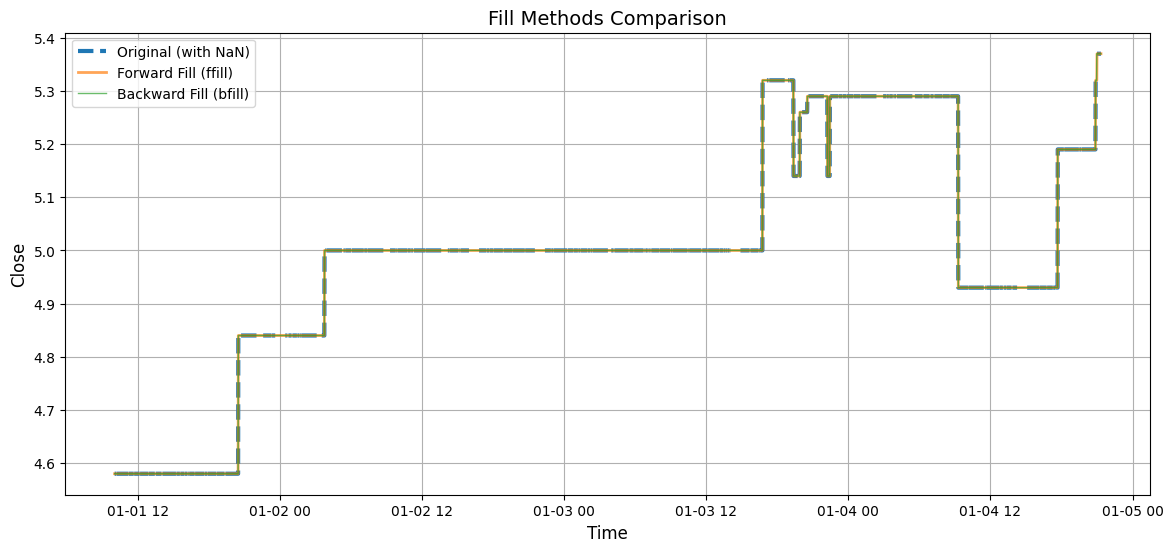

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(close_series, linestyle='--', linewidth=3, label='Original (with NaN)')

plt.plot(close_ffill, linewidth=2, label='Forward Fill (ffill)', alpha=0.7)

plt.plot(close_bfill, linewidth=1,label='Backward Fill (bfill)', alpha=0.7)

plt.title("Fill Methods Comparison", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Close", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

- ffill và bfill đều tạo ra dạng đường bậc thang: giá được giữ nguyên trong suốt khoảng trống cho tới khi gặp điểm có dữ liệu tiếp theo.

- Cách này đơn giản và ổn định, nhưng làm mất biến động nội tại trong các đoạn thiếu dài → chuỗi trở nên “phẳng” hơn thực tế.

- Phù hợp khi giả định rằng giá không thay đổi giữa các giao dịch, nhưng có thể gây sai lệch nếu thị trường biến động mạnh.

#### 4.2 Interpolation methods

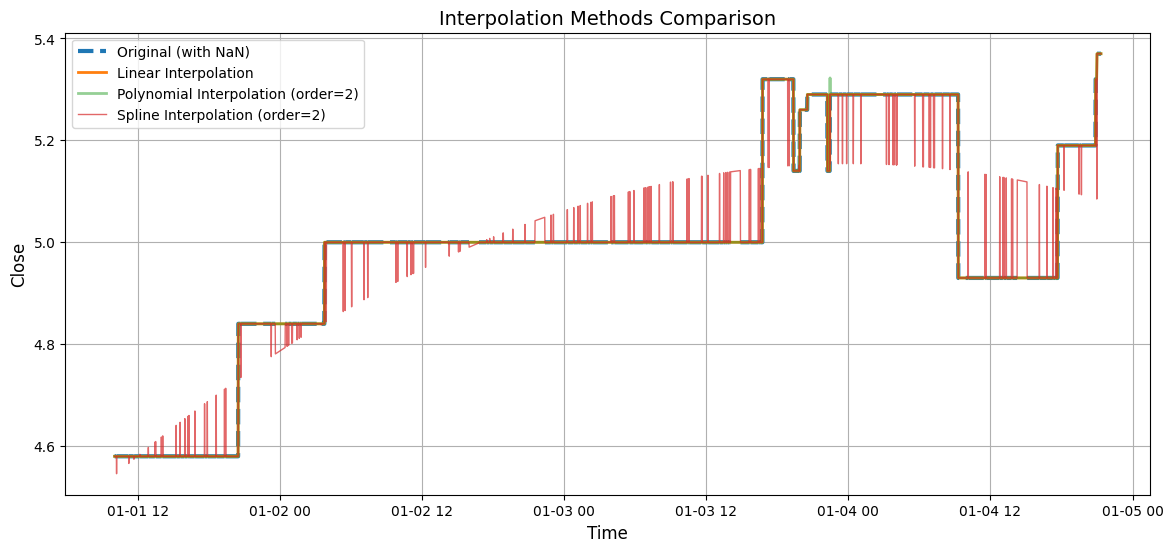

In [13]:
plt.figure(figsize=(14, 6))

plt.plot(close_series, linestyle='--', linewidth=3, label='Original (with NaN)')

plt.plot(close_linear, linewidth=2, label='Linear Interpolation')

plt.plot(close_polynomial, linewidth=2, label='Polynomial Interpolation (order=2)', alpha=0.5)

plt.plot(close_spline, linewidth=1, label='Spline Interpolation (order=2)', alpha=0.7)

plt.title("Interpolation Methods Comparison", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Close", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

- **Linear interpolation:**

    - Nối thẳng giữa hai điểm quan sát → tạo xu hướng mượt, hợp lý khi khoảng trống ngắn.

    - Giữ được hướng đi chung của chuỗi mà không tạo dao động giả.

- **Polynomial / Spline (order = 2):**

    - Tạo đường cong mượt hơn nhưng trong biểu đồ có thể thấy dao động mạnh ở biên và xuất hiện các “gợn sóng” không phản ánh đúng hành vi giá.

    - Dễ bị overfit và sinh ra biến động giả trong dữ liệu tài chính.

## C. Time-Based Feature Extraction

Từ cột `datetime`, xây dựng các đặc trưng phục vụ mô hình gồm:  
- **Đặc trưng tuần hoàn** (ngày trong tuần, tháng, giờ).  
- **Biến chỉ báo** (cuối tuần, ngày lễ).  
- **Mã hóa sin/cos** để biểu diễn tính chu kỳ liên tục của thời gian.  
- **Khoảng thời gian từ sự kiện** (ví dụ: số ngày còn lại đến/đã qua ngày lễ).

Những đặc trưng này giúp mô hình học được yếu tố mùa vụ và ngữ cảnh thời gian, từ đó cải thiện khả năng dự báo.


### 1. Extract Cyclical Time Features

Trích xuất các đặc trưng **day of week, month, hour, day of year** từ `datetime index`. Những giá trị này mang tính **chu kỳ** (ví dụ: Thứ 7 và Chủ nhật gần nhau về ý nghĩa hơn so với Thứ 7 và Thứ 2).  

In [14]:
df = data_indexed.copy()

df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['day_of_year'] = df.index.dayofyear

month_to_season = {1:1, 2:1, 3:1, 4:2, 5:2, 6:2, 7:3, 8:3, 9:3, 10:4, 11:4, 12:4}
df['season'] = df['month'].map(month_to_season)

In [15]:
display(df[['day_of_week', 'month', 'day_of_year', 'season']].head(10))

,day_of_week,month,day_of_year,season
datetime,,,,
2012-01-01 10:01:00,6,1,1,1
2012-01-01 10:02:00,6,1,1,1
2012-01-01 10:03:00,6,1,1,1
2012-01-01 10:04:00,6,1,1,1
2012-01-01 10:05:00,6,1,1,1
2012-01-01 10:06:00,6,1,1,1
2012-01-01 10:07:00,6,1,1,1
2012-01-01 10:08:00,6,1,1,1
2012-01-01 10:09:00,6,1,1,1


### 2. Create Indicator Variables for Special Periods

Tạo các cột nhị phân (0/1) cho những khoảng thời gian đặc biệt như **cuối tuần**, **ngày lễ**, v.v.  
Các biến chỉ báo này giúp mô hình phân biệt hành vi giữa **ngày thường** và **ngày đặc biệt** (ví dụ: thanh khoản và biến động giá thường thấp hơn vào cuối tuần hoặc ngày lễ).


In [16]:
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)  # 5=Saturday, 6=Sunday

holidays = [
    # New Year
    '2012-01-01','2013-01-01','2014-01-01','2015-01-01','2016-01-01','2017-01-01',
    '2018-01-01','2019-01-01','2020-01-01','2021-01-01','2022-01-01','2023-01-01',
    '2024-01-01','2025-01-01','2026-01-01',

    # Christmas
    '2012-12-25','2013-12-25','2014-12-25','2015-12-25','2016-12-25','2017-12-25',
    '2018-12-25','2019-12-25','2020-12-25','2021-12-25','2022-12-25','2023-12-25',
    '2024-12-25','2025-12-25','2026-12-25',

    # US Independence Day
    '2012-07-04','2013-07-04','2014-07-04','2015-07-04','2016-07-04','2017-07-04',
    '2018-07-04','2019-07-04','2020-07-04','2021-07-04','2022-07-04','2023-07-04',
    '2024-07-04','2025-07-04','2026-07-04',

    # Thanksgiving (US) – Thursday of 4th week in Nov
    '2012-11-22','2013-11-28','2014-11-27','2015-11-26','2016-11-24','2017-11-23',
    '2018-11-22','2019-11-28','2020-11-26','2021-11-25','2022-11-24','2023-11-23',
    '2024-11-28','2025-11-27','2026-11-26',

    # Black Friday (day after Thanksgiving)
    '2012-11-23','2013-11-29','2014-11-28','2015-11-27','2016-11-25','2017-11-24',
    '2018-11-23','2019-11-29','2020-11-27','2021-11-26','2022-11-25','2023-11-24',
    '2024-11-29','2025-11-28','2026-11-27',
]

lunar_new_year_periods = {
    2012: ('2012-01-22','2012-01-28'),
    2013: ('2013-02-09','2013-02-15'),
    2014: ('2014-01-30','2014-02-05'),
    2015: ('2015-02-18','2015-02-24'),
    2016: ('2016-02-07','2016-02-13'),
    2017: ('2017-01-27','2017-02-02'),
    2018: ('2018-02-15','2018-02-21'),
    2019: ('2019-02-04','2019-02-10'),
    2020: ('2020-01-24','2020-01-30'),
    2021: ('2021-02-11','2021-02-17'),
    2022: ('2022-01-31','2022-02-06'),
    2023: ('2023-01-21','2023-01-27'),
    2024: ('2024-02-09','2024-02-15'),
    2025: ('2025-01-28','2025-02-03'),
    2026: ('2026-02-16','2026-02-22'),
}

df['date_only'] = df.index.strftime('%Y-%m-%d')
df['is_holiday'] = df['date_only'].isin(holidays).astype(int)
df.drop(columns=['date_only'], inplace=True)

for year, (start, end) in lunar_new_year_periods.items():
    mask = (df.index >= start) & (df.index <= end)
    df.loc[mask, "is_holiday"] = 1

display(df[['day_of_week', 'is_weekend', 'is_holiday']].head(10))

,day_of_week,is_weekend,is_holiday
datetime,,,
2012-01-01 10:01:00,6,1,1
2012-01-01 10:02:00,6,1,1
2012-01-01 10:03:00,6,1,1
2012-01-01 10:04:00,6,1,1
2012-01-01 10:05:00,6,1,1
2012-01-01 10:06:00,6,1,1
2012-01-01 10:07:00,6,1,1
2012-01-01 10:08:00,6,1,1
2012-01-01 10:09:00,6,1,1


### 3. Encode Cyclical Features with Sine and Cosine

Thay vì dùng giá trị rời rạc (ví dụ 0–6 cho day of week, 0–23 cho hour), ta mã hóa bằng **sin** và **cos** với chu kỳ tương ứng  
(7 cho ngày trong tuần, 24 cho giờ, 12 cho tháng, 365 cho ngày trong năm).

Cặp giá trị *(sin, cos)* biểu diễn một góc trên đường tròn nên:
- Liên tục theo thời gian  
- Không có “điểm nhảy” giữa cuối chu kỳ và đầu chu kỳ (ví dụ từ Chủ nhật → Thứ Hai)  
- Phù hợp cho các mô hình học máy và deep learning.


In [17]:
def cyclical_sin_cos(series, period):
    """Map values in [0, period) to sin and cos (period = 2*pi)."""
    x = 2 * np.pi * series / period
    return np.sin(x), np.cos(x)

# Day of week: period 7
df['dow_sin'], df['dow_cos'] = cyclical_sin_cos(df['day_of_week'], 7)

# Month: period 12
df['month_sin'], df['month_cos'] = cyclical_sin_cos(df['month'], 12)

# Hour: period 24
df['hour_sin'], df['hour_cos'] = cyclical_sin_cos(df['hour'], 24)

# Day of year: period 365 (or 366 for leap years)
year = df.index.year
is_leap = ((year % 4 == 0) & ((year % 100 != 0) | (year % 400 == 0)))
df['doy_sin'], df['doy_cos'] = cyclical_sin_cos(df['day_of_year'], 365 + is_leap)

display(df[['day_of_week', 'dow_sin', 'dow_cos', 'month', 'month_sin', 'month_cos', 'hour', 'hour_sin', 'hour_cos']].head(10))

,day_of_week,dow_sin,dow_cos,month,month_sin,month_cos,hour,hour_sin,hour_cos
datetime,,,,,,,,,
2012-01-01 10:01:00,6,-0.781831,0.62349,1,0.5,0.866025,10,0.5,-0.866025
2012-01-01 10:02:00,6,-0.781831,0.62349,1,0.5,0.866025,10,0.5,-0.866025
2012-01-01 10:03:00,6,-0.781831,0.62349,1,0.5,0.866025,10,0.5,-0.866025
2012-01-01 10:04:00,6,-0.781831,0.62349,1,0.5,0.866025,10,0.5,-0.866025
2012-01-01 10:05:00,6,-0.781831,0.62349,1,0.5,0.866025,10,0.5,-0.866025
2012-01-01 10:06:00,6,-0.781831,0.62349,1,0.5,0.866025,10,0.5,-0.866025
2012-01-01 10:07:00,6,-0.781831,0.62349,1,0.5,0.866025,10,0.5,-0.866025
2012-01-01 10:08:00,6,-0.781831,0.62349,1,0.5,0.866025,10,0.5,-0.866025
2012-01-01 10:09:00,6,-0.781831,0.62349,1,0.5,0.866025,10,0.5,-0.866025


### 4. Time Since Specific Events

Tính **số ngày (hoặc số phút) kể từ** một mốc tham chiếu — ví dụ: từ đầu năm, từ nửa đêm, hoặc từ ngày lễ gần nhất.  

Đặc trưng này giúp mô hình nắm được “khoảng cách thời gian” đến các sự kiện có ảnh hưởng, chẳng hạn như đã bao lâu kể từ kỳ nghỉ lễ gần nhất hoặc còn bao lâu nữa đến một mốc quan trọng.


In [18]:
df['Timestamp_temp'] = pd.to_datetime(df['Timestamp'], unit='s')
# Chuẩn hóa
df = df.sort_values('Timestamp_temp')
holidays_df = pd.DataFrame({'holiday': pd.to_datetime(holidays)}).sort_values('holiday')
    
# Merge tìm holiday gần nhất phía TRƯỚC
df = pd.merge_asof(df, holidays_df, left_on='Timestamp_temp', right_on='holiday', direction='backward')
df.rename(columns={'holiday': 'last_holiday'}, inplace=True)

# Merge tìm holiday gần nhất phía SAU
df = pd.merge_asof(df, holidays_df, left_on='Timestamp_temp', right_on='holiday', direction='forward', suffixes=('', '_next'))
df.rename(columns={'holiday': 'next_holiday'}, inplace=True)

# Tính số ngày
df['days_since_last_holiday'] = (df['Timestamp_temp'] - df['last_holiday']).dt.days
df['days_until_next_holiday'] = (df['next_holiday'] - df['Timestamp_temp']).dt.days

In [19]:
display(df[['days_since_last_holiday', 'days_until_next_holiday']].head(10))

,days_since_last_holiday,days_until_next_holiday
0,0,184
1,0,184
2,0,184
3,0,184
4,0,184
5,0,184
6,0,184
7,0,184
8,0,184
9,0,184


In [20]:
# Convert lunar periods to one flat DatetimeIndex
lunar_ranges = []
for y, (start, end) in lunar_new_year_periods.items():
    lunar_ranges.append(pd.date_range(start, end))

lunar_dates = pd.to_datetime(np.concatenate(lunar_ranges))

lunar_df = pd.DataFrame({'lunar_date': lunar_dates}).sort_values('lunar_date')

df = pd.merge_asof(
    df, lunar_df,
    left_on='Timestamp_temp',
    right_on='lunar_date',
    direction='backward'
)

df['days_since_lunar_new_year'] = (df['Timestamp_temp'] - df['lunar_date']).dt.days

df = pd.merge_asof(
    df, lunar_df,
    left_on='Timestamp_temp',
    right_on='lunar_date',
    direction='forward',
    suffixes=('', '_next')
)

df['days_until_lunar_new_year'] = (df['lunar_date_next'] - df['Timestamp_temp']).dt.days

In [21]:
display(df[['days_since_lunar_new_year', 'days_until_lunar_new_year']].head(10))

,days_since_lunar_new_year,days_until_lunar_new_year
0,NaN,20
1,NaN,20
2,NaN,20
3,NaN,20
4,NaN,20
5,NaN,20
6,NaN,20
7,NaN,20
8,NaN,20
9,NaN,20


In [22]:
# Time elapsed since specific events (reference timestamps)
start_of_data = df.index.min()

df['days_since_start'] = (df['Timestamp_temp'] - df['Timestamp_temp'].min()).dt.days
df['hours_since_start'] = (df['Timestamp_temp'] - df['Timestamp_temp'].min()).dt.total_seconds() / 3600

# Days since start of same year
df['days_since_year_start'] = (
    df['Timestamp_temp'] - df['Timestamp_temp'].dt.to_period('Y').dt.to_timestamp()
).dt.days

# Minutes since midnight (for intraday)
df['minutes_since_midnight'] = df['Timestamp_temp'].dt.hour * 60 + df['Timestamp_temp'].dt.minute

In [23]:
display(df[['days_since_start', 'hours_since_start', 'days_since_year_start', 'minutes_since_midnight']].tail(10))

,days_since_start,hours_since_start,days_since_year_start,minutes_since_midnight
7402709,5141,123397.816667,27,1430
7402710,5141,123397.833333,27,1431
7402711,5141,123397.850000,27,1432
7402712,5141,123397.866667,27,1433
7402713,5141,123397.883333,27,1434
7402714,5141,123397.900000,27,1435
7402715,5141,123397.916667,27,1436
7402716,5141,123397.933333,27,1437
7402717,5141,123397.950000,27,1438
7402718,5141,123397.966667,27,1439


In [24]:
df.drop(columns=['lunar_date', 'lunar_date_next', 'Timestamp_temp'], inplace=True)

## D. Time Series Resampling

Thay đổi tần suất của chuỗi thời gian:  
- **Down-sampling** (gộp nhiều phút thành 1h / 4h / 1 ngày) để phục vụ phân tích dài hạn và giảm nhiễu.  
- **Up-sampling** (chia dữ liệu 1h thành 30 phút, 15 phút, …) thường đi kèm với các kỹ thuật điền giá trị hoặc nội suy khi cần đồng bộ với chuỗi có tần suất cao hơn.

Resampling giúp linh hoạt điều chỉnh độ phân giải thời gian cho phù hợp với mục tiêu phân tích và mô hình.


In [25]:
ts_ohlc = data_indexed[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
ts_ohlc.head()

,Open,High,Low,Close,Volume
datetime,,,,,
2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.0
2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.0
2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.0
2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.0
2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.0


### 1. Down-Sampling (Aggregate Data)

Thực hiện gộp dữ liệu theo các khung thời gian **1h, 4h, 1D** với quy tắc OHLC:  
- Open = giá mở đầu  
- High = giá cao nhất  
- Low = giá thấp nhất  
- Close = giá đóng cuối  
- Volume = tổng khối lượng  

Down-sampling giúp giảm số lượng điểm dữ liệu, làm rõ xu hướng tổng thể và phù hợp cho các mô hình dự báo theo nến 1h hoặc 1D. Có thể so sánh số dòng và một vài dòng đầu của từng tần suất để kiểm tra tính hợp lý của kết quả.


In [26]:
resampled_1h = ts_ohlc.resample('1h').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum',
})
resampled_4h = ts_ohlc.resample('4h').agg({
    'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum',
})
resampled_1D = ts_ohlc.resample('1D').agg({
    'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum',
})

print("1-hour (downsampled):", resampled_1h.shape[0], "rows")
print("4-hour (downsampled):", resampled_4h.shape[0], "rows")
print("1-day (downsampled):", resampled_1D.shape[0], "rows")
display(resampled_1D.head())

1-hour (downsampled): 123398 rows
4-hour (downsampled): 30850 rows
1-day (downsampled): 5142 rows


,Open,High,Low,Close,Volume
datetime,,,,,
2012-01-01,4.58,4.84,4.58,4.84,10.000000
2012-01-02,4.84,5.00,4.84,5.00,10.100000
2012-01-03,5.00,5.32,5.00,5.29,107.085281
2012-01-04,5.29,5.57,4.93,5.57,107.233260
2012-01-05,5.57,6.46,5.57,6.42,70.328742


In [27]:
resampled_1h_mean = ts_ohlc.resample('1h').agg({
    'Open': 'mean', 'High': 'max', 'Low': 'min', 'Close': 'mean', 'Volume': 'sum',
})

print("OHLC with mean(Open, Close) vs first/last:")
display(pd.concat([
    resampled_1h_mean.head(3).add_suffix('_mean'),
    resampled_1h.head(3).add_suffix('_ohlc'),
], axis=1))

OHLC with mean(Open, Close) vs first/last:


,Open_mean,High_mean,Low_mean,Close_mean,Volume_mean,Open_ohlc,High_ohlc,Low_ohlc,Close_ohlc,Volume_ohlc
datetime,,,,,,,,,,
2012-01-01 10:00:00,4.58,4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,0.0
2012-01-01 11:00:00,4.58,4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,0.0
2012-01-01 12:00:00,4.58,4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,0.0


### 2. Upsampling (Increase Frequency)

Chia mỗi nến 1 giờ thành hai nến 30 phút bằng phương pháp **forward fill**: giá của 30 phút đầu và 30 phút sau đều lấy từ nến 1h ban đầu.

**Nhận xét:** Cách này đơn giản và phù hợp khi mục tiêu chủ yếu là đồng bộ lại chỉ số thời gian (index). Nếu cần chuỗi giá “mượt” và phản ánh biến động liên tục hơn, có thể áp dụng nội suy **linear** hoặc **spline** cho từng cột.


In [28]:
base_1h = ts_ohlc.resample('1h').agg({
    'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum',
}).dropna(how='all')

upsampled_30min = base_1h.resample('30min').asfreq()

up_open = base_1h['Open'].resample('30min').ffill()
up_high = base_1h['High'].resample('30min').ffill()
up_low = base_1h['Low'].resample('30min').ffill()
up_close = base_1h['Close'].resample('30min').ffill()
up_vol = base_1h['Volume'].resample('30min').ffill()
upsampled_30min = pd.DataFrame({'Open': up_open, 'High': up_high, 'Low': up_low, 'Close': up_close, 'Volume': up_vol})

print("Upsampled 1h -> 30min (forward fill):")
print(upsampled_30min.head(6))

Upsampled 1h -> 30min (forward fill):
                     Open  High   Low  Close  Volume
datetime                                            
2012-01-01 10:00:00  4.58  4.58  4.58   4.58     0.0
2012-01-01 10:30:00  4.58  4.58  4.58   4.58     0.0
2012-01-01 11:00:00  4.58  4.58  4.58   4.58     0.0
2012-01-01 11:30:00  4.58  4.58  4.58   4.58     0.0
2012-01-01 12:00:00  4.58  4.58  4.58   4.58     0.0
2012-01-01 12:30:00  4.58  4.58  4.58   4.58     0.0


In [29]:
close_1min = ts_ohlc['Close']
close_1h = resampled_1h['Close'].dropna()
close_4h = resampled_4h['Close'].dropna()
close_1D = resampled_1D['Close'].dropna()

stats = pd.DataFrame({
    '1min': [close_1min.count(), close_1min.mean(), close_1min.std(), close_1min.min(), close_1min.max()],
    '1h':   [close_1h.count(),   close_1h.mean(),   close_1h.std(),   close_1h.min(),   close_1h.max()],
    '4h':   [close_4h.count(),   close_4h.mean(),   close_4h.std(),   close_4h.min(),   close_4h.max()],
    '1D':   [close_1D.count(),   close_1D.mean(),   close_1D.std(),   close_1D.min(),   close_1D.max()],
}, index=['count', 'mean', 'std', 'min', 'max'])
stats.index.name = 'statistic'
print("Close price — effect of resampling frequency:")
display(stats)

Close price — effect of resampling frequency:


,1min,1h,4h,1D
statistic,,,,
count,7.402719e+06,123380.000000,30847.000000,5142.000000
mean,2.203993e+04,22040.792838,22044.031409,22054.442429
std,3.064058e+04,30641.023648,30643.977501,30656.460643
min,3.800000e+00,4.140000,4.170000,4.380000
max,1.262020e+05,126111.000000,125481.000000,124728.000000


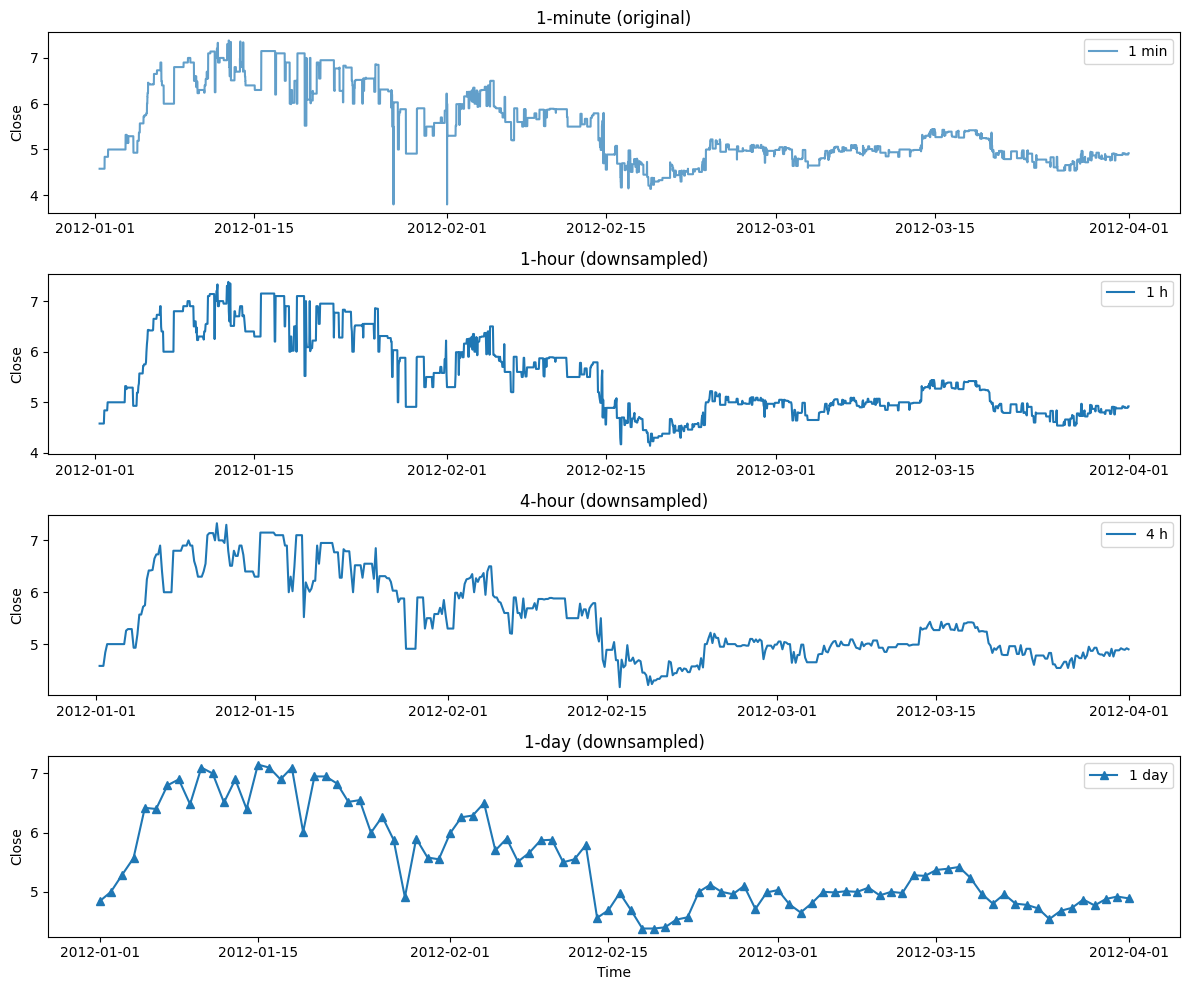

In [30]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=False)
axes[0].plot(close_1min[close_1min.index <= '2012-04-01'].index, close_1min[close_1min.index <= '2012-04-01'].values, alpha=0.7, label='1 min')
axes[0].set_ylabel('Close')
axes[0].set_title('1-minute (original)')
axes[0].legend(loc='upper right')

axes[1].plot(close_1h[close_1h.index <= '2012-04-01'].index, close_1h[close_1h.index <= '2012-04-01'].values, label='1 h')
axes[1].set_ylabel('Close')
axes[1].set_title('1-hour (downsampled)')
axes[1].legend(loc='upper right')

axes[2].plot(close_4h[close_4h.index <= '2012-04-01'].index, close_4h[close_4h.index <= '2012-04-01'].values, label='4 h')
axes[2].set_ylabel('Close')
axes[2].set_title('4-hour (downsampled)')
axes[2].legend(loc='upper right')

axes[3].plot(close_1D[close_1D.index <= '2012-04-01'].index, close_1D[close_1D.index <= '2012-04-01'].values, marker='^', markersize=6, label='1 day')
axes[3].set_ylabel('Close')
axes[3].set_xlabel('Time')
axes[3].set_title('1-day (downsampled)')
axes[3].legend(loc='upper right')

plt.tight_layout()
plt.show()

**Nhận xét từ các biểu đồ resample:**

1. **1-minute (original):**

   * Dao động rất “nhiễu”, nhiều spike ngắn hạn.
   * Phù hợp cho phân tích vi mô, nhưng khó nhìn xu hướng dài hạn.

2. **1-hour (downsampled):**

   * Đã mượt hơn rõ rệt, vẫn giữ được cấu trúc chính của biến động.
   * Tốt cho mô hình dự báo ngắn–trung hạn (intraday / swing).

3. **4-hour (downsampled):**

   * Nhiễu giảm mạnh, xu hướng lên–xuống nhìn rất rõ.
   * Phù hợp để phát hiện trend và các pha đảo chiều lớn.

4. **1-day (downsampled):**

   * Rất mượt, chỉ còn các điểm đại diện mỗi ngày.
   * Mất nhiều thông tin chi tiết trong ngày, nhưng rất tốt cho phân tích dài hạn.

**Kết luận:**

* Down-sampling giúp **giảm nhiễu và làm rõ xu hướng**, nhưng càng gộp mạnh thì càng **mất thông tin ngắn hạn**.
* Chọn tần suất phụ thuộc mục tiêu:

  * Giao dịch ngắn hạn → 1m, 1h
  * Phân tích xu hướng / dự báo dài hạn → 4h, 1D


## E. Lag and Rolling Statistical Features

Phần này xây dựng các **đặc trưng lag** (giá tại *t−1, t−2, …*), **thống kê rolling** (trung bình trượt, độ lệch chuẩn trên các cửa sổ thời gian), và **đặc trưng sai phân** (hiệu giữa hai thời điểm liên tiếp).

Phân tích ACF/PACF giúp chọn số bậc lag phù hợp. Các đặc trưng này cung cấp cho mô hình “bộ nhớ ngắn hạn”, thông tin về xu hướng cục bộ và mức độ biến động, từ đó cải thiện chất lượng dự báo chuỗi thời gian.


### Autocorrelation and Choosing Appropriate Lag Values

**Autocorrelation là gì?**  

Autocorrelation (tự tương quan) đo mức độ liên hệ giữa chuỗi thời gian với chính nó ở các độ trễ khác nhau. Ở lag $k$, nó đo tương quan giữa $y_t$ và $y_{t-k}$. Nếu tự tương quan tại một lag lớn, điều đó cho thấy giá trị trong quá khứ ở lag đó chứa thông tin hữu ích để dự báo giá trị hiện tại.

**Vì sao autocorrelation quan trọng?**

- **Tạo đặc trưng (feature engineering):** Các giá trị trễ như $y_{t-1}, y_{t-2}, \ldots$ là đầu vào phổ biến cho mô hình dự báo. Autocorrelation giúp xác định lag nào thực sự có ý nghĩa.
- **Xác định cấu trúc mô hình:** ACF và PACF được dùng để chọn bậc $p, q$ trong các mô hình ARIMA.
- **Kiểm tra tính dừng:** ACF giảm rất chậm thường cho thấy chuỗi không dừng (có xu hướng), gợi ý cần sai phân trước khi mô hình hóa.

**Cơ sở lựa chọn số lượng và giá trị lag**

1. **Dựa trên ACF (Autocorrelation Function)**  
   Các lag mà ACF vượt ra ngoài dải tin cậy được xem là có ý nghĩa thống kê. Đây là những ứng viên tốt để đưa vào làm lag features hoặc xác định bậc MA $q$.

2. **Dựa trên PACF (Partial Autocorrelation Function)**  
   PACF tại lag $k$ đo tương quan giữa $y_t$ và $y_{t-k}$ sau khi loại bỏ ảnh hưởng của các lag trước đó. Điểm “cắt” của PACF thường gợi ý số lượng lag trực tiếp cần dùng (bậc AR $p$).

3. **Theo kinh nghiệm và ngữ cảnh dữ liệu**
   - Với dữ liệu theo giờ: lag 1–24 thường phản ánh hiệu ứng trong ngày và ngày trước đó.  
   - Với dữ liệu theo ngày: lag 7 thường đại diện cho chu kỳ tuần.  
   - Nên ưu tiên **mô hình gọn (parsimony)**: bắt đầu với vài lag quan trọng (ví dụ 1–5), rồi đánh giá bằng tập validation hoặc các chỉ số lỗi dự báo.

4. **Áp dụng trong notebook này**  
   Trong notebook, ACF và PACF của chuỗi Close theo 1 giờ được vẽ để xác định các lag có ý nghĩa. Dựa trên đó và để minh họa, ta chọn $n_{\text{lags}} = 5$ và xây dựng các đặc trưng lag $t-1 \ldots t-5$ cho mô hình dự báo.


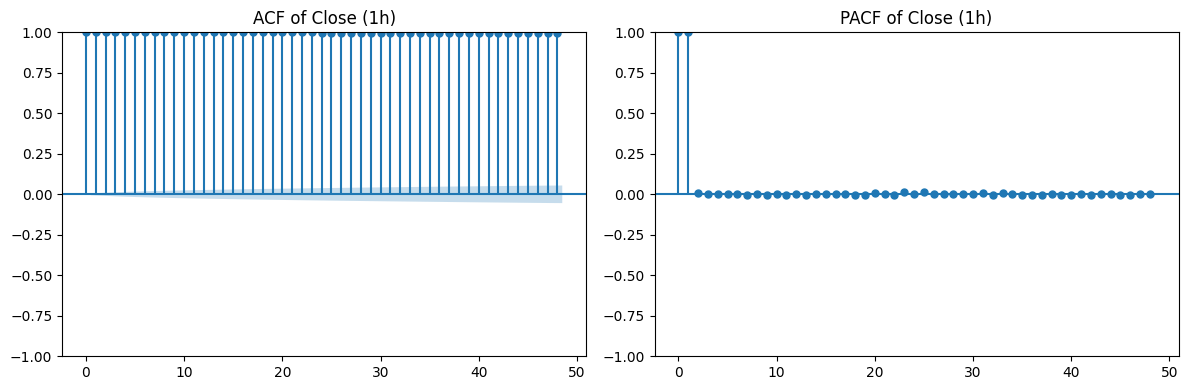

In [31]:
close = close_1h.dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(close, lags=min(48, len(close)//2 - 1), ax=axes[0], title='ACF of Close (1h)')
plot_pacf(close, lags=min(48, len(close)//2 - 1), ax=axes[1], title='PACF of Close (1h)')
plt.tight_layout()
plt.show()

**Nhận xét từ ACF & PACF của Close (1h):**

1. **ACF (Autocorrelation Function):**

   * Các hệ số ACF gần như **rất cao và dương cho hầu hết các độ trễ (lag)**.
   * Điều này cho thấy chuỗi giá Close có **tính phụ thuộc mạnh theo thời gian** → giá hiện tại chịu ảnh hưởng lớn từ các giá trước đó.
   * Dạng ACF giảm rất chậm -> chuỗi **non-stationary**, thường gặp ở chuỗi giá tài chính.

2. **PACF (Partial Autocorrelation Function):**

   * Chỉ có **lag = 1 và lag = 2 là rất lớn và có ý nghĩa**, các lag sau gần như bằng 0 và nằm trong vùng tin cậy.

### 1. Lag Features (t − 1, t − 2, …, t − n)

**Giải thích:**  
Các cột dạng `Close_lag1`, `Close_lag2`, …, `Close_lagn` biểu diễn **giá đóng cửa ở các thời điểm trước đó k bước** so với hiện tại.  
Những đặc trưng này giúp mô hình học được **tính phụ thuộc theo thời gian** (temporal dependency) của chuỗi giá.

- `Close_lag1`: giá tại thời điểm $(t-1)$  
- `Close_lag2`: giá tại thời điểm $(t-2)$  
- …  
- `Close_lagn`: giá tại thời điểm $(t-n)$

In [32]:
n_lags = 5
df_lags = pd.DataFrame(close_1h.dropna())
for k in range(1, n_lags + 1):
    df_lags[f'Close_lag{k}'] = df_lags['Close'].shift(k)
df_lags = df_lags.dropna()
print("Lag features (first 10 rows):")
display(df_lags.head(10))

Lag features (first 10 rows):


,Close,Close_lag1,Close_lag2,Close_lag3,Close_lag4,Close_lag5
datetime,,,,,,
2012-01-01 15:00:00,4.58,4.58,4.58,4.58,4.58,4.58
2012-01-01 16:00:00,4.58,4.58,4.58,4.58,4.58,4.58
2012-01-01 17:00:00,4.58,4.58,4.58,4.58,4.58,4.58
2012-01-01 18:00:00,4.58,4.58,4.58,4.58,4.58,4.58
2012-01-01 19:00:00,4.58,4.58,4.58,4.58,4.58,4.58
2012-01-01 20:00:00,4.84,4.58,4.58,4.58,4.58,4.58
2012-01-01 21:00:00,4.84,4.84,4.58,4.58,4.58,4.58
2012-01-01 22:00:00,4.84,4.84,4.84,4.58,4.58,4.58
2012-01-01 23:00:00,4.84,4.84,4.84,4.84,4.58,4.58


### 2. Rolling Window Statistics

**Giải thích:**  
Tại mỗi thời điểm $(t)$, ta tính các thống kê trên một **cửa sổ trượt (rolling window)** gồm $(k)$ điểm gần nhất, ví dụ 24 giờ:

- `Close_roll_mean_24`: trung bình giá trong 24 giờ gần nhất  
- `Close_roll_std_24`: độ lệch chuẩn giá trong 24 giờ gần nhất  

Những đặc trưng này giúp mô hình nắm được:
- **Xu hướng ngắn hạn** (qua rolling mean)  
- **Mức độ biến động** (qua rolling std)

**Ý nghĩa:**
- Cửa sổ nhỏ → phản ứng nhanh với thay đổi, nhưng dễ nhiễu  
- Cửa sổ lớn → đường giá mượt hơn, nhưng phản ứng chậm

**Ứng dụng:**  
Rolling features rất hữu ích cho:
- Mô hình dự báo giá
- Phát hiện bất thường (volatility spike)
- Đánh giá trạng thái thị trường (ổn định hay biến động mạnh)


In [33]:
window = 24
close = close_1h.dropna()
rolling_mean = close.rolling(window=window, min_periods=1).mean()
rolling_std  = close.rolling(window=window, min_periods=1).std()
df_rolling = pd.DataFrame({
    'Close': close,
    f'rolling_mean_{window}': rolling_mean,
    f'rolling_std_{window}': rolling_std,
}, index=close.index).dropna(how='all')
print(f"Rolling statistics (window={window}):")
display(df_rolling.head(10))

Rolling statistics (window=24):


,Close,rolling_mean_24,rolling_std_24
datetime,,,
2012-01-01 10:00:00,4.58,4.58,NaN
2012-01-01 11:00:00,4.58,4.58,0.0
2012-01-01 12:00:00,4.58,4.58,0.0
2012-01-01 13:00:00,4.58,4.58,0.0
2012-01-01 14:00:00,4.58,4.58,0.0
2012-01-01 15:00:00,4.58,4.58,0.0
2012-01-01 16:00:00,4.58,4.58,0.0
2012-01-01 17:00:00,4.58,4.58,0.0
2012-01-01 18:00:00,4.58,4.58,0.0


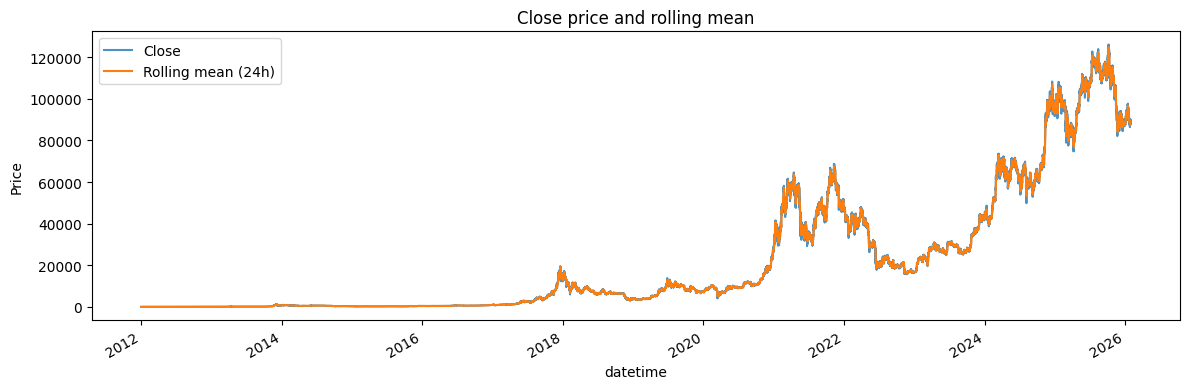

In [34]:
ax = df_rolling['Close'].plot(figsize=(12, 4), label='Close', alpha=0.8)
df_rolling[f'rolling_mean_{window}'].plot(ax=ax, label=f'Rolling mean ({window}h)')
ax.set_ylabel('Price')
ax.legend()
ax.set_title('Close price and rolling mean')
plt.tight_layout()
plt.show()

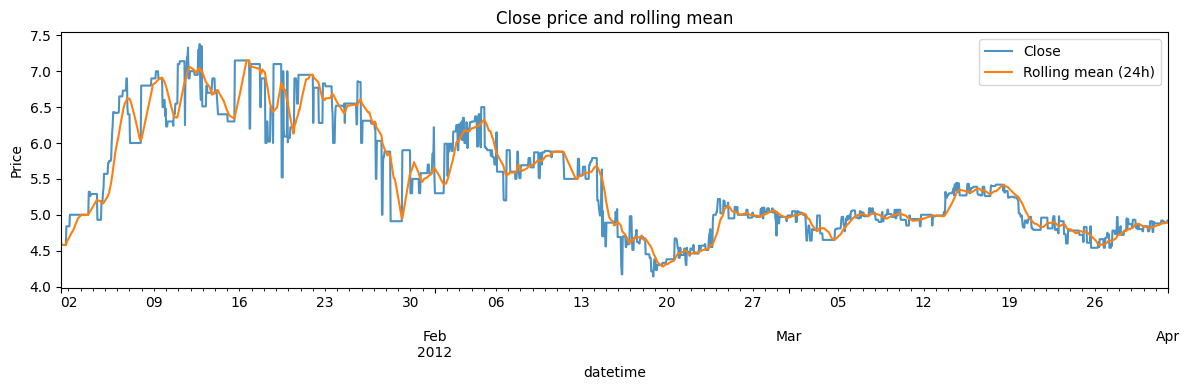

In [35]:
ax = df_rolling['Close'][df_rolling.index <= '2012-04-01'].plot(figsize=(12, 4), label='Close', alpha=0.8)
df_rolling[f'rolling_mean_{window}'][df_rolling.index <= '2012-04-01'].plot(ax=ax, label=f'Rolling mean ({window}h)')
ax.set_ylabel('Price')
ax.legend()
ax.set_title('Close price and rolling mean')
plt.tight_layout()
plt.show()

**Nhận xét từ biểu đồ Close và Rolling Mean (24h):**

1. **Rolling mean làm mượt chuỗi giá**
   Đường Rolling mean (24h) mượt hơn rõ rệt so với giá Close gốc. Nó loại bỏ nhiễu ngắn hạn và thể hiện xu hướng tổng quát tốt hơn.

2. **Độ trễ (lag) của rolling mean**
   Khi giá tăng/giảm mạnh, rolling mean phản ứng chậm hơn vì nó là trung bình của 24 giờ trước đó.
   → Điều này thể hiện rõ ở các đoạn đảo chiều: giá quay đầu trước, rolling mean theo sau.

3. **Phát hiện xu hướng**

   * Giai đoạn đầu: xu hướng tăng rõ (Close và rolling mean cùng đi lên).
   * Giữa tháng 2: xu hướng giảm mạnh, rolling mean cho thấy xu hướng giảm bền vững.
   * Tháng 3: giá đi ngang – rolling mean khá phẳng, phản ánh thị trường ổn định hơn.

4. **Ứng dụng thực tế**

   * Rolling mean phù hợp để:

     * Xác định xu hướng ngắn–trung hạn
     * Làm feature cho mô hình dự báo
     * Làm đường “baseline” so sánh với giá thật (giá vượt xa mean → có thể là biến động bất thường)

**Kết luận:**
Rolling mean 24h giúp nhìn rõ xu hướng và giảm nhiễu, nhưng đánh đổi bằng việc phản ứng chậm với các thay đổi đột ngột của giá.


### 3. Difference Features

**First-order difference:** $(y_t - y_{t-1})$ biểu diễn mức thay đổi (return) của giá tại thời điểm $(t)$. Sai phân giúp làm chuỗi **ổn định hơn** bằng cách loại bỏ xu hướng (trend), từ đó phù hợp với nhiều mô hình dự báo tuyến tính và thống kê.

**Lag-k difference:** $(y_t - y_{t-k})$ nhấn mạnh biến động theo chu kỳ dài hơn (ví dụ theo ngày/tuần). Loại đặc trưng này hữu ích để mô hình học được nhịp điệu và độ mạnh của biến động theo thời gian.


In [36]:
close = close_1h.dropna()
diff_1 = close.diff(1)
diff_2 = close.diff(2)
df_diff = pd.DataFrame({
    'Close': close,
    'diff_1': diff_1,
    'diff_2': diff_2,
}, index=close.index).dropna()
print("Difference features (first 10 rows):")

display(df_diff.head(10))

Difference features (first 10 rows):


,Close,diff_1,diff_2
datetime,,,
2012-01-01 12:00:00,4.58,0.00,0.00
2012-01-01 13:00:00,4.58,0.00,0.00
2012-01-01 14:00:00,4.58,0.00,0.00
2012-01-01 15:00:00,4.58,0.00,0.00
2012-01-01 16:00:00,4.58,0.00,0.00
2012-01-01 17:00:00,4.58,0.00,0.00
2012-01-01 18:00:00,4.58,0.00,0.00
2012-01-01 19:00:00,4.58,0.00,0.00
2012-01-01 20:00:00,4.84,0.26,0.26


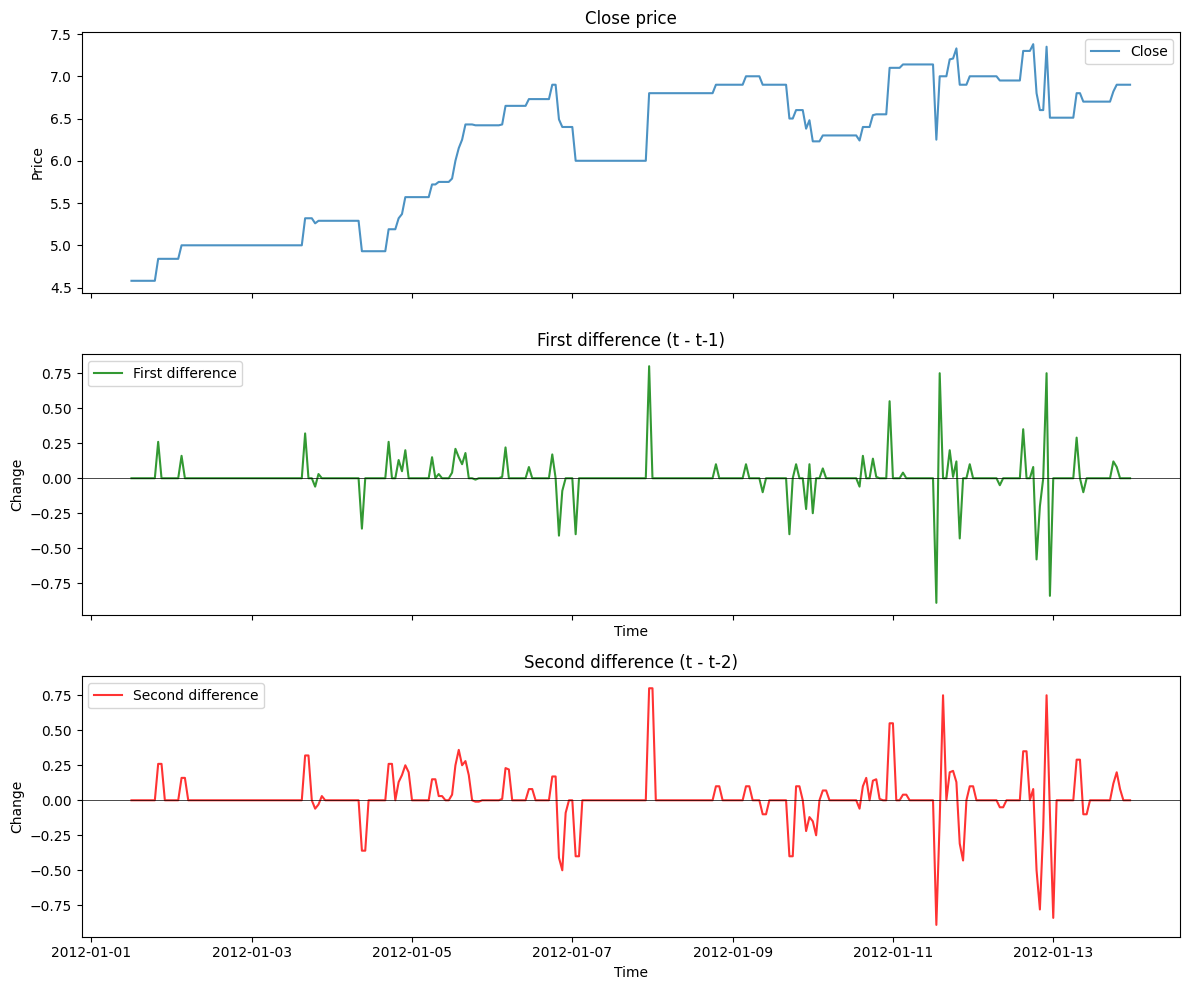

In [37]:
df_diff = df_diff[:300]
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].plot(df_diff.index, df_diff['Close'], alpha=0.8, label='Close')
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].set_title('Close price')

axes[1].plot(df_diff.index, df_diff['diff_1'], alpha=0.8, color='green', label='First difference')
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].set_ylabel('Change')
axes[1].set_xlabel('Time')
axes[1].legend()
axes[1].set_title('First difference (t - t-1)')

axes[2].plot(df_diff.index, df_diff['diff_2'], alpha=0.8, color='red', label='Second difference')
axes[2].axhline(y=0, color='k', linewidth=0.5)
axes[2].set_ylabel('Change')
axes[2].set_xlabel('Time')
axes[2].legend()
axes[2].set_title('Second difference (t - t-2)')
plt.tight_layout()
plt.show()

**1. Close price (giá gốc):**

* Giá biến động theo từng “bậc thang”, có các đoạn đi ngang khá dài → thể hiện tính **stickiness** (giá giữ nguyên nhiều bước rồi mới nhảy).
* Có các cú nhảy rõ rệt lên/xuống, cho thấy thị trường có những thời điểm biến động đột ngột.

**2. First difference (t − t−1):**

* Phần lớn giá trị = 0 → đúng với việc giá gốc thường giữ nguyên nhiều bước.
* Khi có thay đổi, sai phân xuất hiện các spike dương/âm:

  * Spike dương: giá tăng đột ngột.
  * Spike âm: giá giảm mạnh (đặc biệt có một cú giảm sâu quanh 01-04).
* Chuỗi sai phân đã **loại bỏ trend**, dao động quanh 0 → phù hợp hơn cho các mô hình dự báo.

**3. Second difference (t − t−2):**

* Nhấn mạnh mạnh hơn các điểm “đổi tốc” của giá.
* Biên độ dao động lớn hơn ở các điểm có biến động mạnh → thể hiện sự thay đổi trong **động lượng (momentum)**.
* Rất nhạy với nhiễu, nên thường dùng để phát hiện đột biến hơn là dự báo trực tiếp.

**Tổng kết:**

* First difference phù hợp để làm đầu vào mô hình vì ổn định và dễ học.
* Second difference giúp phát hiện các cú sốc/điểm đảo chiều.
* Biểu đồ cho thấy việc tạo **difference features** là hợp lý và đúng mục tiêu: làm chuỗi stationarity hơn và nhấn mạnh biến động thực sự của giá.